# ML Week 17: Object Detection

### YOLO

In [57]:
from ultralytics import YOLO

In [58]:
model = YOLO("yolo12m.pt")

In [59]:
results = model.predict("delacroix1.jpg")


image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week17\delacroix1.jpg: 512x640 1 vase, 253.5ms
Speed: 2.0ms preprocess, 253.5ms inference, 5.6ms postprocess per image at shape (1, 3, 512, 640)


In [60]:
boxes = results[0].boxes

In [61]:
for box in boxes:
    print("Object type:", box.cls)
    print("Coordinates:", box.xyxy)
    print("Probability:", box.conf)

Object type: tensor([75.])
Coordinates: tensor([[138.2010, 215.4529, 329.2735, 308.5843]])
Probability: tensor([0.2882])


In [62]:
# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen

### DETR

In [ ]:
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
from transformers import pipeline

In [7]:
pipeline = pipeline(
    "object-detection",
    model="facebook/detr-resnet-50"
)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
img = Image.open(requests.get(url, stream=True).raw)
outputs = pipeline(url)

In [29]:
outputs

[{'score': 0.9982200264930725,
  'label': 'remote',
  'box': {'xmin': 40, 'ymin': 70, 'xmax': 175, 'ymax': 117}},
 {'score': 0.995998740196228,
  'label': 'remote',
  'box': {'xmin': 333, 'ymin': 72, 'xmax': 368, 'ymax': 187}},
 {'score': 0.9954814910888672,
  'label': 'couch',
  'box': {'xmin': 0, 'ymin': 1, 'xmax': 639, 'ymax': 473}},
 {'score': 0.9988006353378296,
  'label': 'cat',
  'box': {'xmin': 13, 'ymin': 52, 'xmax': 314, 'ymax': 470}},
 {'score': 0.9986791014671326,
  'label': 'cat',
  'box': {'xmin': 345, 'ymin': 23, 'xmax': 640, 'ymax': 368}}]

In [41]:
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

def plot_results(pil_img, outputs):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    color_dict = {}
    for output in outputs:
        prob = output['score']
        label = output['label']
        if label not in color_dict.keys():
            color_dict[label] = colors.pop()
        xmin, ymin, xmax, ymax = list(output['box'].values())
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, color=color_dict[label], fill=False, linewidth=3))
        text = f'{label}: {prob:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

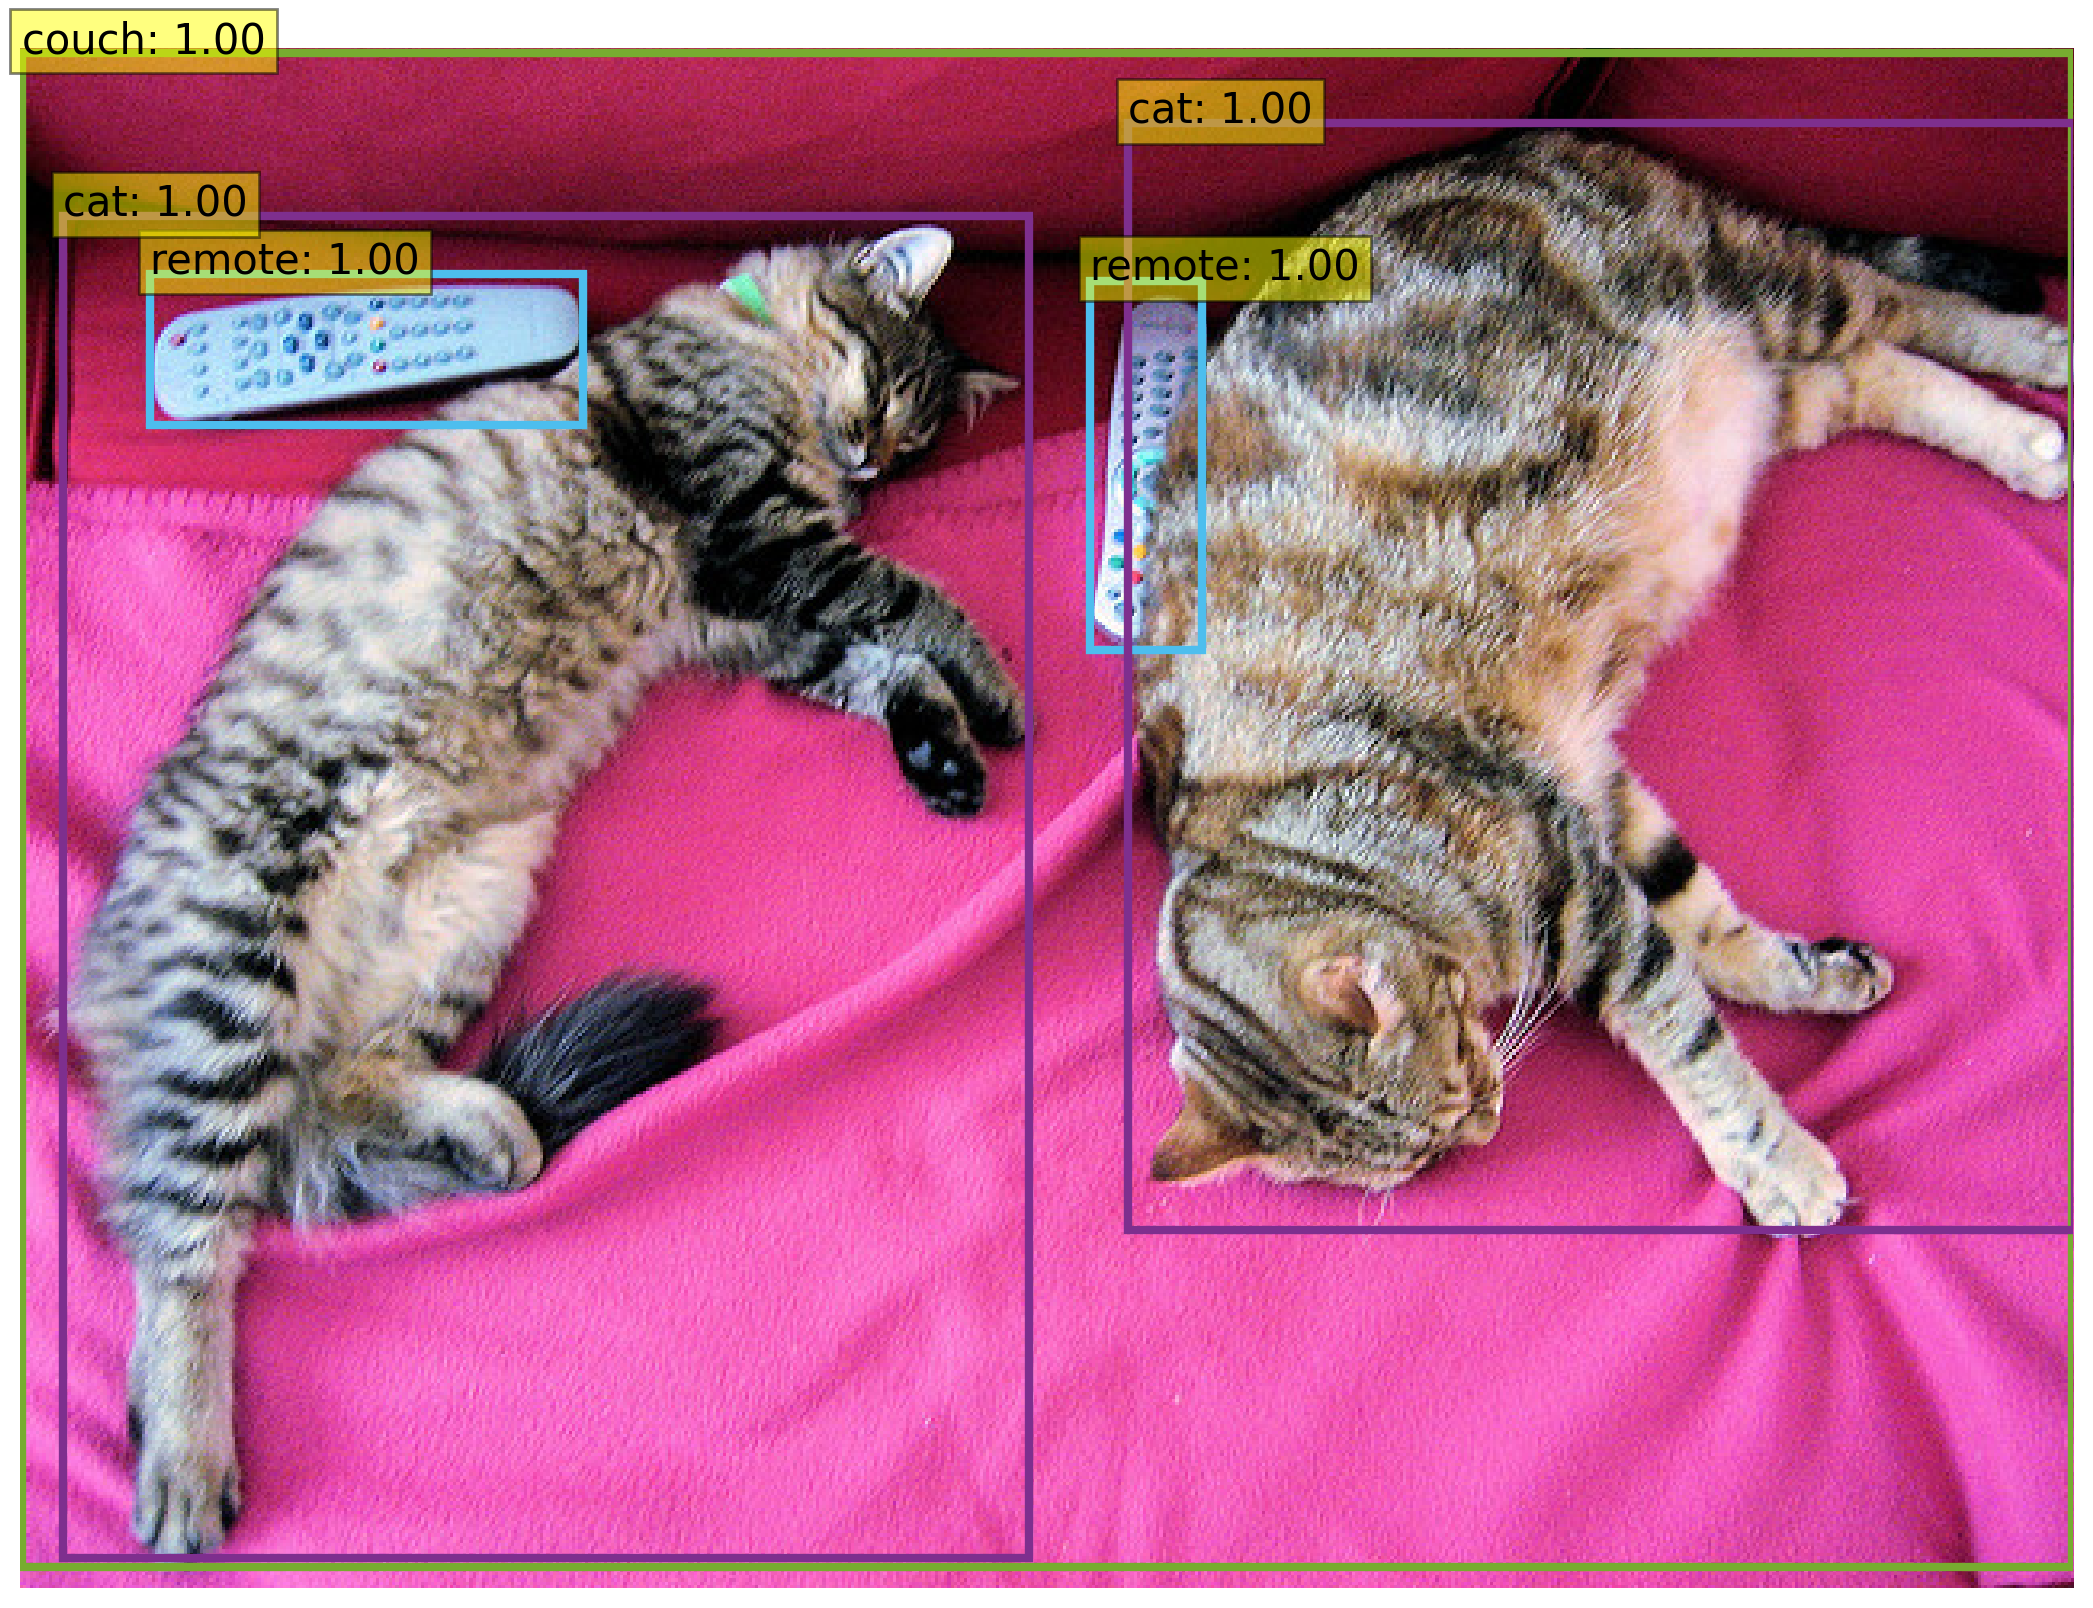

In [ ]:
plot_results(img, outputs)

### DETR

In [51]:
from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR("rtdetr-l.pt")

# Display model information (optional)
model.info()

## Train the model on the COCO8 example dataset for 100 epochs
#results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model(img)

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs

0: 640x640 2 cats, 1 couch, 2 beds, 2 remotes, 466.9ms
Speed: 2.5ms preprocess, 466.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


In [55]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([15., 57., 15., 65., 65., 59., 59.])
conf: tensor([0.9595, 0.9552, 0.9503, 0.9436, 0.9237, 0.3578, 0.2576])
data: tensor([[ 3.4479e+02,  2.4742e+01,  6.4014e+02,  3.7097e+02,  9.5948e-01,  1.5000e+01],
        [ 3.4660e-01, -7.9825e-01,  6.4031e+02,  4.7854e+02,  9.5523e-01,  5.7000e+01],
        [ 1.4613e+01,  5.5131e+01,  3.1814e+02,  4.7202e+02,  9.5035e-01,  1.5000e+01],
        [ 4.0033e+01,  7.3111e+01,  1.7570e+02,  1.1773e+02,  9.4360e-01,  6.5000e+01],
        [ 3.3389e+02,  7.6533e+01,  3.7042e+02,  1.8807e+02,  9.2366e-01,  6.5000e+01],
        [ 8.4469e-01, -9.3555e-03,  6.4084e+02,  4.7730e+02,  3.5778e-01,  5.9000e+01],
        [ 5.1472e-01, -1.1451e+00,  6.4050e+02,  4.7884e+02,  2.5764e-01,  5.9000e+01]])
id: None
is_track: False
orig_shape: (480, 640)
shape: torch.Size([7, 6])
xywh: tensor([[492.4657, 197.8570, 295.3487, 346.2309],
        [320.3282, 238.8723, 639.9631, 479.3411],
        [166.3762, 

In [53]:
# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen